**Q1.**

OK, a warm-up, just to get started.

1. Set up a grid of $K$ equally spaced values between 0 and 1, `{1/K, 2/K, ..., K/K}`.
2. Draw a point from the grid at random with equal probability.
3. For a very small $K$, repeat the above process `n = 5_000` times, and plot the ECDF of the draws.
4. What distribution does this approach as you increase $K$?



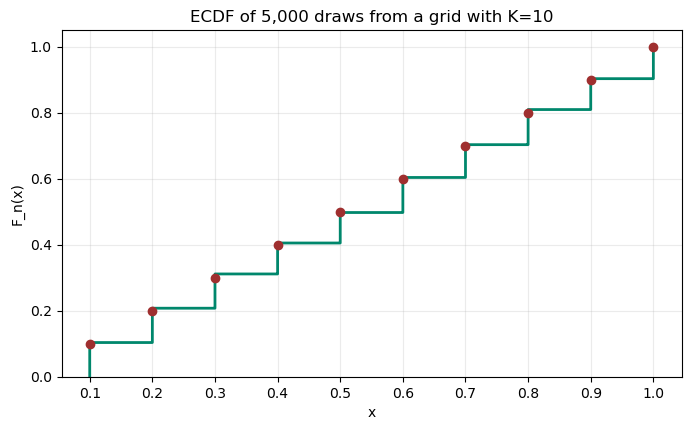

In [3]:
import numpy as np
import matplotlib.pyplot as plt

K = 10
n = 5_000
rng = np.random.default_rng(seed=100)

grid = np.arange(1, K + 1) / K
draws = rng.choice(grid, size=n)

x = np.sort(draws)
y = np.arange(1, n + 1) / n

plt.figure(figsize=(8, 4.5))
plt.step(x, y, where="post", color="#00876c", linewidth=2)
plt.scatter(grid, np.arange(1, K + 1) / K, color="#9f2f2f", zorder=3)
plt.xticks(grid)
plt.xlabel("x")
plt.ylabel("F_n(x)")
plt.title(f"ECDF of {n:,} draws from a grid with K={K}")
plt.ylim(0, 1.05)
plt.grid(alpha=0.25)
plt.show()


Discrete Uniform Distribution

We often study sample averages: It's one of the first statistics you calculate for any dataset. What is the distribution of the sample mean?

1. Draw `n = 32` values from `Uniform[-sqrt(3), sqrt(3)]`; these are your data. The choice of $\pm \sqrt{3}$ ensures each draw has mean 0 and variance 1.
2. For this sample, compute the mean and multiply by `np.sqrt(n)`.
3. Repeat the above process `b = 5_000` times and plot the ECDF.
4. What distribution does this approach as $n$ increases?

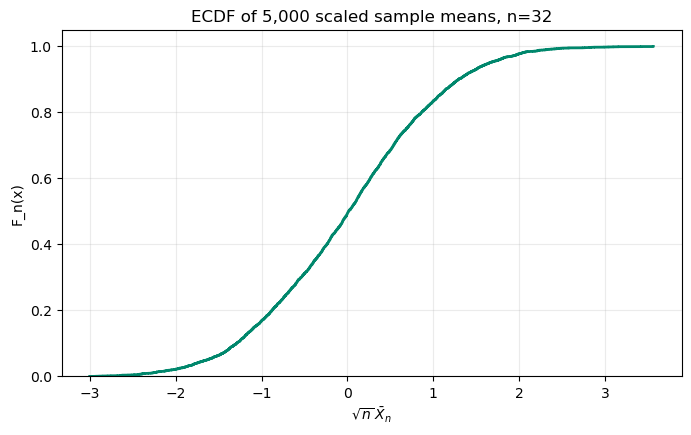

In [4]:
import numpy as np
import matplotlib.pyplot as plt

n = 32
b = 5_000
rng = np.random.default_rng(seed=100)

sample = rng.uniform(-np.sqrt(3), np.sqrt(3), size=(b, n))
scaled_means = sample.mean(axis=1) * np.sqrt(n)

x = np.sort(scaled_means)
y = np.arange(1, b + 1) / b

plt.figure(figsize=(8, 4.5))
plt.step(x, y, where="post", color="#00876c", linewidth=2)
plt.xlabel(r"$\sqrt{n}\,\bar{X}_n$")
plt.ylabel("F_n(x)")
plt.title(f"ECDF of {b:,} scaled sample means, n={n}")
plt.ylim(0, 1.05)
plt.grid(alpha=0.25)
plt.show()


continuous normal distribution

A process is running in discrete time. In each time interval of length `dt`, it terminates with probability `r * dt`, where `r * dt < 1`. This is called an arrival, death, or survival process, and is popular for modeling how long patients live after a procedure, whether an employee quits, or the arrival of the next goal in a sportsball match.

1. For each simulation of the process, determine the period in which termination occurs.
2. Convert periods to time by multiplying by `dt`.
3. Repeat the simulation `n = 5_000` times and plot the ECDF, for a value of `dt` close to zero (e.g. `dt = 1e-3`).
4. What distribution does this approach as $dt$ goes to zero?
5. How do the results change as you adjust $r$?

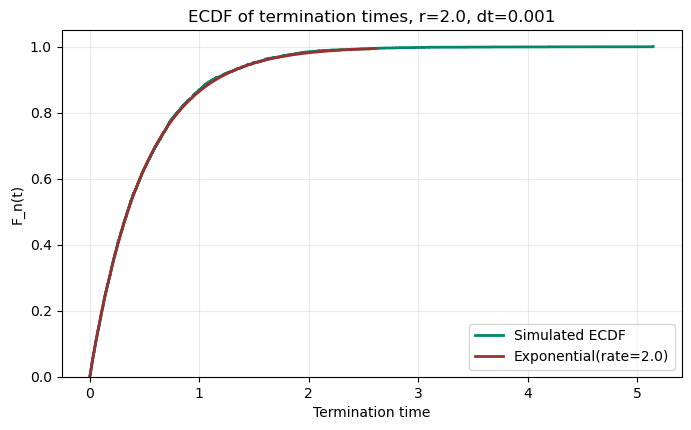

In [5]:
import numpy as np
import matplotlib.pyplot as plt

r = 2.0
dt = 1e-3
n = 5_000
rng = np.random.default_rng(seed=100)

termination_probability = r * dt
termination_periods = rng.geometric(p=termination_probability, size=n)
termination_times = termination_periods * dt

x = np.sort(termination_times)
y = np.arange(1, n + 1) / n

plt.figure(figsize=(8, 4.5))
plt.step(x, y, where="post", color="#00876c", linewidth=2, label="Simulated ECDF")

# Limiting distribution as dt approaches zero: Exponential(rate=r).
theoretical_x = np.linspace(0, np.quantile(termination_times, 0.995), 500)
theoretical_cdf = 1 - np.exp(-r * theoretical_x)
plt.plot(theoretical_x, theoretical_cdf, color="#9f2f2f", linewidth=2, label=f"Exponential(rate={r})")

plt.xlabel("Termination time")
plt.ylabel("F_n(t)")
plt.title(f"ECDF of termination times, r={r}, dt={dt}")
plt.ylim(0, 1.05)
plt.grid(alpha=0.25)
plt.legend()
plt.show()


Exponential distribution: increasing r will make the cdf increase faster which moves the graph to the right. Decreasing r will make the cdf increase slower which moves the graph to the left. 

Many things in the world grow through a long sequence of small proportional gains and losses: prices bounce around in response to information, tumors grow and shrink, populations expand and contract. When those tiny changes accumulate randomly over time, they produce recognizable patterns.

1. Start at a state of `1`.
2. Split a unit of time into $1/\Delta$ small time steps. Start with $\Delta = 1/100$, so $\{0, 1/100, 2/100, ... 99/100\}$.
3. Each period, the state is multiplied by $u = exp(\sqrt{\Delta})$ with probability $p=1/2$ or multiplied by $d = exp(-\sqrt{\Delta})$ with probability $1-p=1/2$.
4. Repeat steps 1-3 `B = 1_000` times and record the final position, and plot the ECDF of your sample.
5. What distribution does this approach as $\Delta$ gets close to zero?

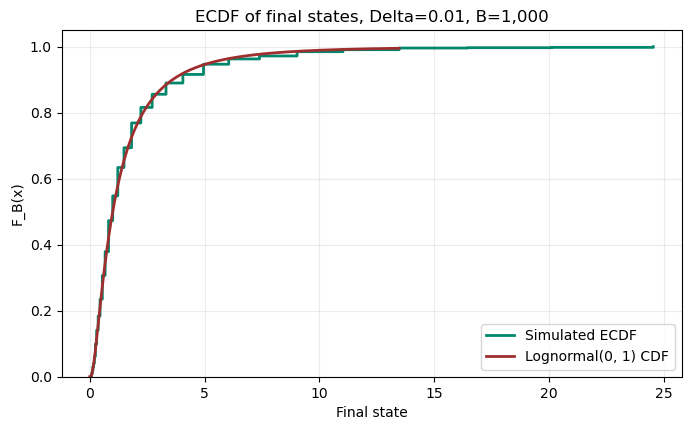

In [7]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import lognorm

Delta = 1 / 100
B = 1_000
steps = int(1 / Delta)
p = 1 / 2
rng = np.random.default_rng(seed=100)

u = np.exp(np.sqrt(Delta))
d = np.exp(-np.sqrt(Delta))

moves = rng.choice([u, d], size=(B, steps), p=[p, 1 - p])
final_states = moves.prod(axis=1)

x = np.sort(final_states)
y = np.arange(1, B + 1) / B

plt.figure(figsize=(8, 4.5))
plt.step(x, y, where="post", color="#00876c", linewidth=2, label="Simulated ECDF")

theoretical_x = np.linspace(0, np.quantile(final_states, 0.995), 500)
theoretical_cdf = lognorm.cdf(theoretical_x, s=1, scale=1)
plt.plot(theoretical_x, theoretical_cdf, color="#9f2f2f", linewidth=2, label="Lognormal(0, 1) CDF")

plt.xlabel("Final state")
plt.ylabel("F_B(x)")
plt.title(f"ECDF of final states, Delta={Delta:g}, B={B:,}")
plt.ylim(0, 1.05)
plt.grid(alpha=0.25)
plt.legend()
plt.show()


Log normal distribution